In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [1]:
import gzip
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hla_8digit_vcf = '../data/1000G_ONT/HLA_typed/1KG_ONT_8digits.unrel.qc.no_monomorphic.vcf.gz'
hla_4digit_vcf = '../data/1000G_ONT/HLA_typed/1KG_ONT_4digits_matched.unrel.vcf.gz'

In [3]:
# Load HLA allele matrix
def load_hla(vcf, mac_threshold):
    header = None
    samples = None
    
    with gzip.open(vcf, 'rt') as ifile:
        for line in ifile:
            if line.startswith("#CHROM"):
                header = line.rstrip().split('\t')
                assert len(header) > 9
                samples = header[9:]
                break
    
    assert header is not None
    assert samples is not None and len(samples) > 0
    
    rows = []
    for sample in samples:
        rows.append(dict())
    
    with gzip.open(vcf, 'rt') as ifile:
        for line in ifile:
            if line.startswith('#'): continue
            fields = dict(zip(header, line.rstrip().split('\t')))
            allele = fields['ID'].removeprefix('HLA-')
    
            # Keep only classical Class I and Class II
            if allele.split('*')[0] not in {'A', 'B', 'C', 'DPA1', 'DPB1', 'DQA1', 'DQB1', 'DRA', 'DRB1'}: continue
            
            format_field = fields['FORMAT'].split(':')
            for i, sample in enumerate(samples):
                sample_field = dict(zip(format_field, fields[sample].split(':')))
                gt = sample_field['GT']
                if gt == './.':
                    gt = np.nan
                else:
                    gt = sum(float(x) for x in gt.split('/'))
                rows[i][allele] = gt
            
    hla_df = pd.DataFrame(rows)
    
    # check if no monomorphic
    assert all(hla_df.var() > 0) 
    
    # Remove alleles by MAC
    mac = hla_df.sum(axis=0)
    hla_df = hla_df.loc[:, mac >= mac_threshold]
    return hla_df

# correlation matrix
def comp_corr(df):
    corr = df.corr(method = "pearson")
    # correlation matrix should have no NAs
    assert corr.isna().sum().sum() == 0
    return corr

# Compute Eigenvalues
def eigenvalues(corr):
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.sort(eigvals)[::-1]
    return sum(eigvals > 1)

# Compute effective tests
def compute_meff(corr):
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.sort(eigvals)[::-1]
    li_ji_contrib = np.minimum(eigvals, 1)
    cum_meff = np.cumsum(li_ji_contrib)
    final_meff = cum_meff[-1]
    return final_meff


In [4]:

series = []
for mac in [1, 5]:
    hla4d_df = load_hla(hla_4digit_vcf, mac)
    s1 = hla4d_df.columns.to_series().apply(lambda x: x.split('*')[0]).value_counts().sort_index().rename(f"4-digit MAC>={mac}")
    s1.loc['Total'] = s1.sum()
    series.append(s1)
    hla8d_df = load_hla(hla_8digit_vcf, mac)
    s2 = hla8d_df.columns.to_series().apply(lambda x: x.split('*')[0]).value_counts().sort_index().rename(f"8-digit MAC>={mac}")
    s2.loc['Total'] = s2.sum()
    series.append(s2)
    s3 = s2 / s1
    s3 = s3.rename('Fold increase')
    series.append(s3)
    
               
pd.concat(series, axis = 1)

,4-digit MAC>=1,8-digit MAC>=1,Fold increase,4-digit MAC>=5,8-digit MAC>=5,Fold increase
A,41,59,1.439024,26,28,1.076923
B,58,96,1.655172,43,53,1.232558
C,28,65,2.321429,24,36,1.500000
DPA1,7,27,3.857143,5,14,2.800000
DPB1,31,100,3.225806,18,25,1.388889
DQA1,14,33,2.357143,13,26,2.000000
DQB1,17,59,3.470588,16,33,2.062500
DRA,2,28,14.000000,2,22,11.000000
DRB1,38,109,2.868421,28,36,1.285714
Total,236,576,2.440678,175,273,1.560000


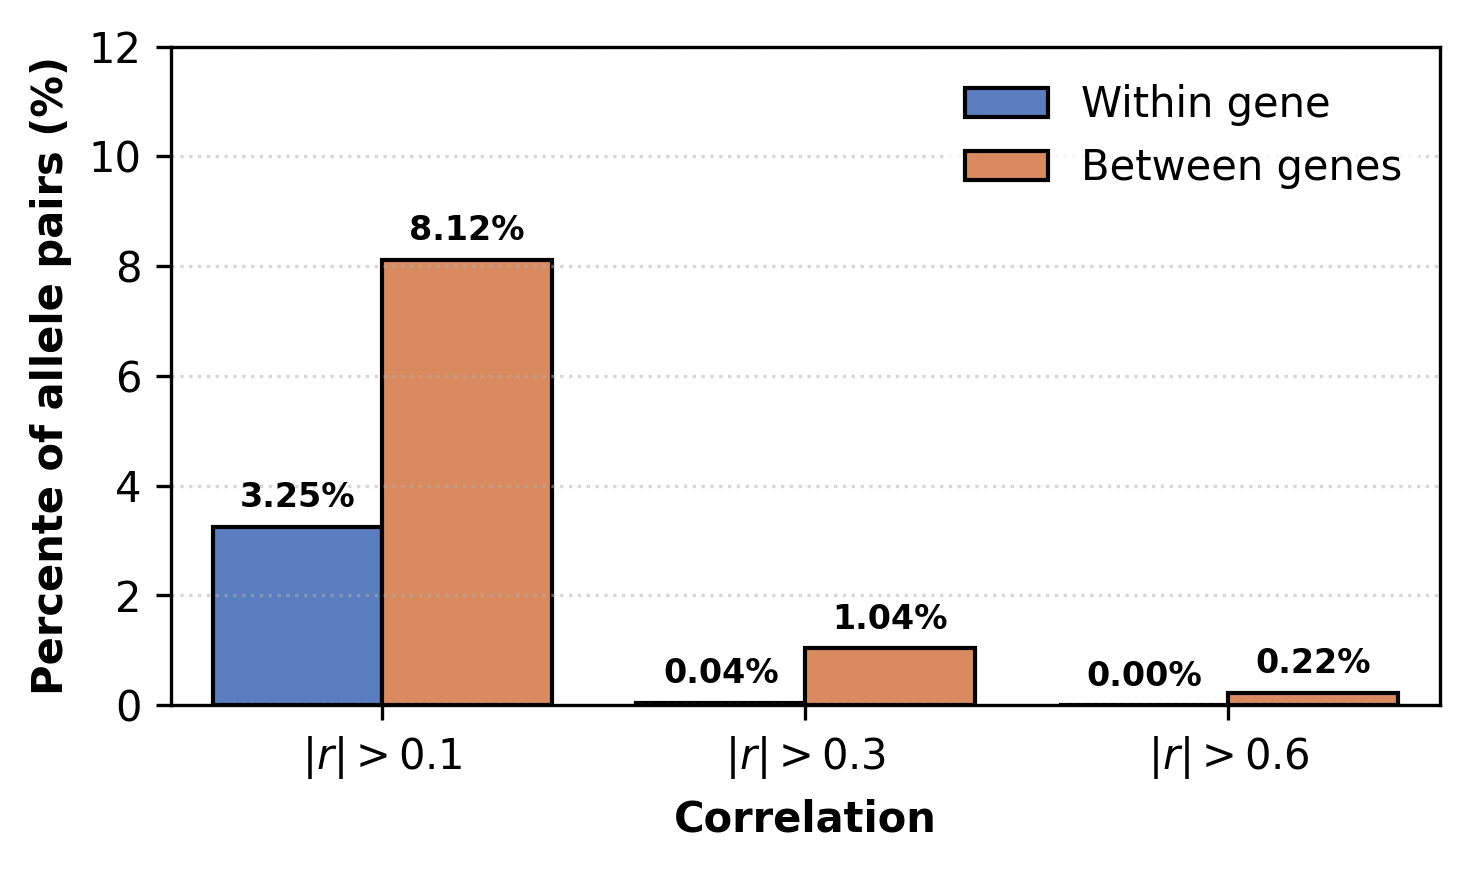

In [5]:
# 8-digit alleles

fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

hla8d_df = load_hla(hla_8digit_vcf, 5)
corr = comp_corr(hla8d_df)


# Collect correlation coefficient for alleles within the same gene and alleles between different genes.
within = []
between = []

for allele1, allele2 in combinations(corr.columns, 2):
    r = corr.loc[allele1, allele2]
    assert not pd.isna(r) # We made sure that there are no NAs in the correlation matrix because of MAC >= 5
    gene1 = allele1.split('*')[0]
    gene2 = allele2.split('*')[0]
    if gene1 == gene2:
        within.append(r)
    else:
        between.append(r)

within = np.array(within)
between = np.array(between)

thresholds = [0.1, 0.3, 0.6]

plot_df = []
for t in thresholds:
    within_pct = ((np.abs(within) > t).sum() / len(within)) * 100
    between_pct = ((np.abs(between) > t).sum() / len(between)) * 100
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Within gene", "Percentage": within_pct})
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Between genes", "Percentage": between_pct})
plot_df = pd.DataFrame(plot_df)

sns.barplot(
    ax = ax,
    data = plot_df,
    x = "Threshold",
    y = "Percentage",
    hue = "Type",
    hue_order = ["Within gene", "Between genes"],
    palette = "muted",
    edgecolor = "black",
    linewidth = 1
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt = "%.2f%%", 
        label_type = "edge", 
        padding = 3, 
        fontsize = 8, 
        fontweight = "bold"
    )

ax.set_ylabel("Percente of allele pairs (%)", fontsize = 10, fontweight = "bold")
ax.set_xlabel("Correlation", fontsize = 10, fontweight = "bold")


ax.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=0)
ax.set_ylim(0, 12) 

plt.legend(loc = "upper right", frameon = True, facecolor = "white", edgecolor = "none")
plt.tight_layout()
plt.show()


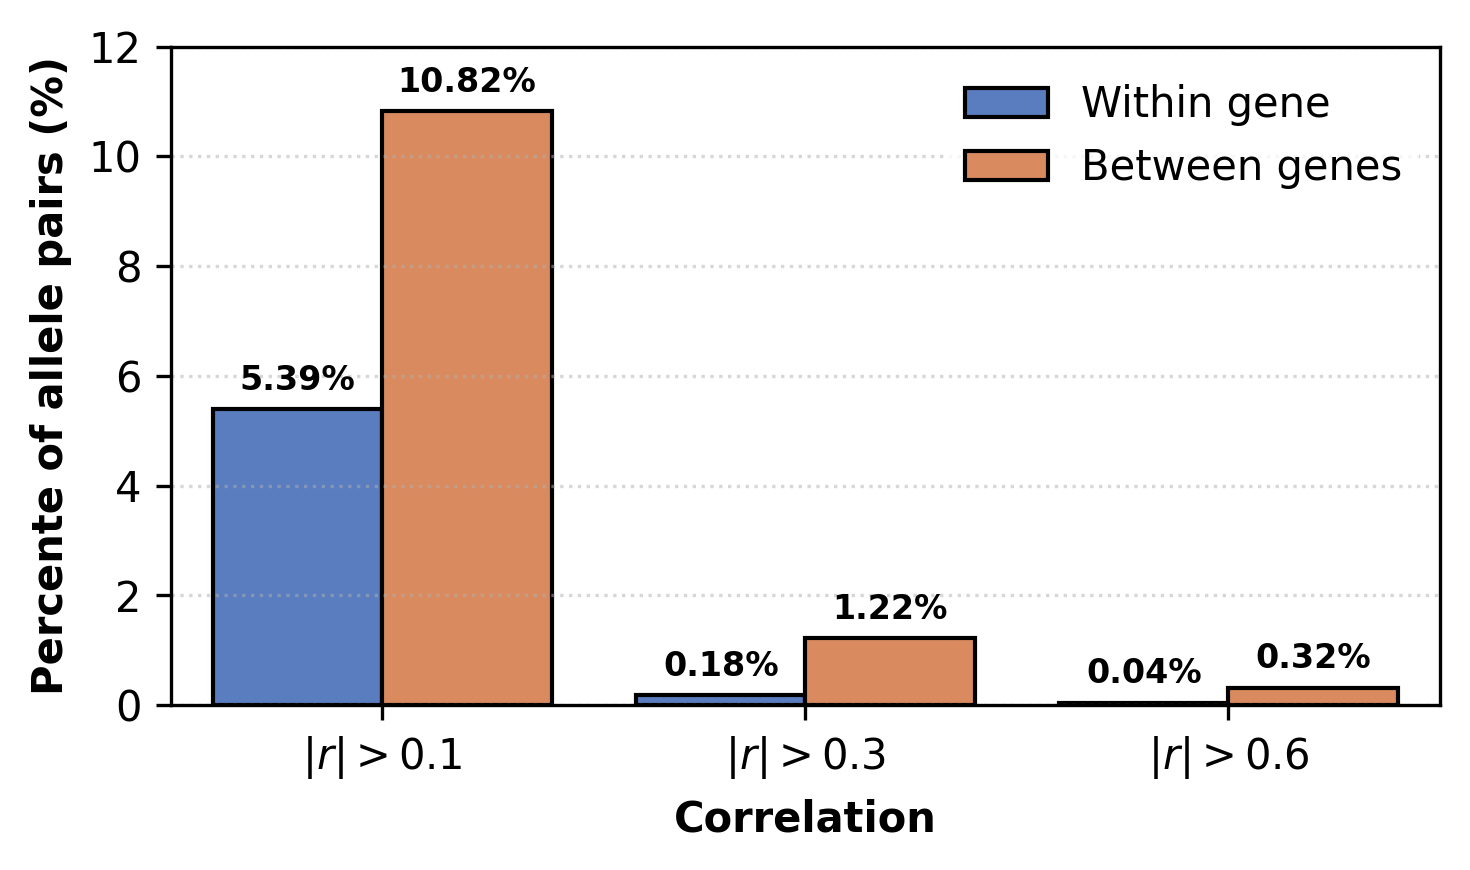

In [6]:
# 4-digit alleles

fig, ax = plt.subplots(figsize = (5, 3), dpi = 300)

hla4d_df = load_hla(hla_4digit_vcf, 5)
corr = comp_corr(hla4d_df)


# Collect correlation coefficient for alleles within the same gene and alleles between different genes.
within = []
between = []

for allele1, allele2 in combinations(corr.columns, 2):
    r = corr.loc[allele1, allele2]
    assert not pd.isna(r) # We made sure that there are no NAs in the correlation matrix because of MAC >= 5
    gene1 = allele1.split('*')[0]
    gene2 = allele2.split('*')[0]
    if gene1 == gene2:
        within.append(r)
    else:
        between.append(r)

within = np.array(within)
between = np.array(between)

thresholds = [0.1, 0.3, 0.6]

plot_df = []
for t in thresholds:
    within_pct = ((np.abs(within) > t).sum() / len(within)) * 100
    between_pct = ((np.abs(between) > t).sum() / len(between)) * 100
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Within gene", "Percentage": within_pct})
    plot_df.append({"Threshold": f"$|r| > {t}$", "Type": "Between genes", "Percentage": between_pct})
plot_df = pd.DataFrame(plot_df)

sns.barplot(
    ax = ax,
    data = plot_df,
    x = "Threshold",
    y = "Percentage",
    hue = "Type",
    hue_order = ["Within gene", "Between genes"],
    palette = "muted",
    edgecolor = "black",
    linewidth = 1
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt = "%.2f%%", 
        label_type = "edge", 
        padding = 3, 
        fontsize = 8, 
        fontweight = "bold"
    )

ax.set_ylabel("Percente of allele pairs (%)", fontsize = 10, fontweight = "bold")
ax.set_xlabel("Correlation", fontsize = 10, fontweight = "bold")


ax.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=0)
ax.set_ylim(0, 12) 

plt.legend(loc = "upper right", frameon = True, facecolor = "white", edgecolor = "none")
plt.tight_layout()
plt.show()


In [7]:
# Print top strongest (r > 0.5) positive correlations in 8-digits
hla8d_df = load_hla(hla_8digit_vcf, 5)
corr = comp_corr(hla8d_df)

upper = corr.where(
    np.triu(np.ones(corr.shape), k = 1).astype(bool)
)
for (allele1, allele2), r  in upper.stack().sort_values(ascending = False).items():
    if r < 0.5:
        break
    ac1 = hla8d_df[allele1].sum()
    ac2 = hla8d_df[allele2].sum()
    print(f'{allele1}\t{allele2}\t{ac1:.0f}\t{ac2:.0f}\t{r:.2f}')

DRA*01:02:02:14	DQA1*06:01:01:02	13	20	0.96
C*03:02:02:05	B*58:01:01:03	22	19	0.95
DRA*01:01:01:11	DQA1*01:05:01:01	16	18	0.94
C*12:02:02:01	B*52:01:01:02	17	17	0.91
C*08:02:01:01	B*14:02:01:01	15	14	0.91
DQA1*01:03:01:02	DQB1*06:03:01:01	25	23	0.89
DRA*01:02:02:04	DQB1*06:09:01:01	18	21	0.89
C*07:18:01:01	B*58:01:01:01	17	14	0.88
DRB1*13:01:01:01	DQA1*01:03:01:02	26	25	0.88
C*06:02:01:02	B*50:01:01:01	9	12	0.86
DRA*01:01:01:13	DQA1*01:01:02:01	13	9	0.84
DPA1*01:03:01:05	DPB1*04:02:01:02	85	97	0.83
DQA1*02:01:01:01	DQB1*02:02:01:01	104	74	0.83
DQA1*01:01:02:01	DQB1*05:01:01:01	9	13	0.83
DQA1*05:01:01:01	DQB1*02:01:01:01	32	43	0.82
DQA1*01:01:01:01	DQB1*05:01:01:03	44	53	0.81
DRB1*13:01:01:01	DQB1*06:03:01:01	26	23	0.81
DRB1*01:01:01:01	DQB1*05:01:01:03	38	53	0.81
C*17:01:01:02	B*42:01:01:01	23	13	0.80
DQA1*03:02:01:01	DQB1*03:03:02:02	32	40	0.80
DRB1*07:01:01:01	DQA1*02:01:01:01	75	104	0.80
DRB1*01:01:01:01	DQA1*01:01:01:01	38	44	0.80
C*15:05:02:01	B*07:05:01:01	8	5	0.79
DRA*01:01:01:1

In [8]:
# Print top strongest (r > 0.4) positive correlations in 4-digits
hla4d_df = load_hla(hla_4digit_vcf, 5)
corr = comp_corr(hla4d_df)

upper = corr.where(
    np.triu(np.ones(corr.shape), k = 1).astype(bool)
)
for (allele1, allele2), r  in upper.stack().sort_values(ascending = False).items():
    if r < 0.4:
        break
    ac1 = hla4d_df[allele1].sum()
    ac2 = hla4d_df[allele2].sum()
    print(f'{allele1}\t{allele2}\t{ac1:.0f}\t{ac2:.0f}\t{r:.2f}')

C*12:02	B*52:01	19	17	0.95
C*08:02	B*14:02	16	14	0.95
DRB1*07:01	DQA1*02:01	100	104	0.93
DQA1*04:01	DQB1*04:02	54	59	0.89
DRB1*13:01	DQB1*06:03	29	26	0.86
DRB1*10:01	DQA1*01:05	20	18	0.85
DQA1*05:01	DQB1*02:01	55	43	0.83
DQA1*03:01	DQB1*03:02	90	83	0.83
DRB1*01:01	DQA1*01:01	39	62	0.82
C*17:01	B*42:01	23	14	0.81
C*15:05	B*07:05	8	5	0.79
DQA1*02:01	DQB1*02:02	104	80	0.78
DQA1*01:01	DQB1*05:01	62	97	0.75
A*29:01	B*07:05	6	5	0.73
C*03:02	B*58:01	22	33	0.72
DRB1*03:01	DQB1*02:01	57	43	0.71
A*02:07	B*46:01	11	19	0.71
DRB1*11:02	DQB1*03:19	6	10	0.71
DRB1*04:03	DQB1*03:02	50	83	0.71
DRB1*07:01	DQB1*02:02	100	80	0.71
DRB1*04:03	DQA1*03:01	50	90	0.69
DPA1*02:02	DPB1*05:01	128	72	0.69
DRB1*09:01	DQA1*03:02	81	40	0.68
DRB1*12:02	DQA1*06:01	11	20	0.67
C*05:01	B*44:02	37	28	0.67
DQA1*03:02	DQB1*03:03	40	74	0.67
DQA1*01:04	DQB1*05:03	46	36	0.67
C*02:02	B*27:05	19	16	0.66
DQA1*05:05	DQB1*03:01	75	112	0.65
DRB1*04:05	DQB1*04:01	12	7	0.65
DRB1*03:01	DQA1*05:01	57	55	0.63
B*08:01	DQB1*02:01	34	43	0.63
D

In [9]:
mac_column = [5, 10, 20, 50]
hld4d_n_alleles_column = []
hld4d_n_pcs_column = []
hld4d_m_eff_column = []
hld8d_n_alleles_column = []
hld8d_n_pcs_column = []
hld8d_m_eff_column = []

for mac in mac_column:
    hla4d_df = load_hla(hla_4digit_vcf, mac)
    corr = comp_corr(hla4d_df)
    hld4d_n_alleles_column.append(len(corr))
    hld4d_n_pcs_column.append(eigenvalues(corr))
    hld4d_m_eff_column.append(compute_meff(corr))
    hla8d_df = load_hla(hla_8digit_vcf, mac)
    corr = comp_corr(hla8d_df)
    hld8d_n_alleles_column.append(len(corr))
    hld8d_n_pcs_column.append(eigenvalues(corr))
    hld8d_m_eff_column.append(compute_meff(corr))

pd.DataFrame({
    'MAC': mac_column,
    '2-field N alleles': hld4d_n_alleles_column,
    '2-field N PCs Lambda > 1': hld4d_n_pcs_column,
    '2-field M_eff': hld4d_m_eff_column,
    '4-field N alleles': hld8d_n_alleles_column,
    '4-field N PCs Lambda > 1': hld8d_n_pcs_column,
    '4-field M_eff': hld8d_m_eff_column,
})

,MAC,2-field N alleles,2-field N PCs Lambda > 1,2-field M_eff,4-field N alleles,4-field N PCs Lambda > 1,4-field M_eff
0,5,175,64,104.670168,273,96,149.938365
1,10,137,50,81.560169,183,63,104.130568
2,20,94,34,56.861848,109,37,65.612758
3,50,46,17,28.590508,28,11,19.087064
